Dữ liệu được khởi tạo bằng cách lấy ngẫu nhiên 500 điểm cho mỗi cụm theo phân phối chuẩn có kỳ vọng lần lượt là (2,2) , (8,3) , (3 , 6) , ma trận hiệp phương sai giống nhau và là ma trận đơn vị

In [2]:
from __future__ import print_function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import cdist
import random

In [4]:

np.random.seed(42)
means = [[2,2],[8,3],[3,6]]
cov = [[1,0],[0,1]]
N = 500
X0 = np.random.multivariate_normal(means[0], cov , N)
X1 = np.random.multivariate_normal(means[1], cov , N)
X2 = np.random.multivariate_normal(means[2], cov , N)
X = np.concatenate((X0,X1,X2),axis = 0)
K = 3
original_label = np.asarray([0]*N + [1]*N + [2]*N).T

In [5]:
#Khởi tạo tâm cụm
def kmeans_init_centroids(X , k):
  return X[np.random.choice(X.shape[0],k,replace = False)]

In [6]:
#Tìm nhãn mới cho các điểm khi biết tâm các cụm
def kmeans_assign_labels(X , centroids) :
  distance = cdist(X , centroids)
  return np.argmin(distance, axis = 1) # trả về vị trí min gần nhất tâm cụm

In [7]:
# Kiểm tra điều kiện dừng
def has_converged(centroids , new_centroids):
  #return True if two set centroids are the same
  return (set([tuple(a) for a in centroids]) == set([tuple(a) for a in new_centroids]))

In [8]:
# Cập nhật tâm cụm khi biết nhãn từng điểm
def kmeans_update_centroids(X , labels , K):
  centroids = np.zeros((K,X.shape[1]))
  for k in range(K):
    Xk = X[labels == k , :]
    centroids[k,:] = np.mean(Xk,axis = 0)
  return centroids

In [9]:
def kmeans(X , K) :
  centroids = [kmeans_init_centroids(X , K)]
  labels = []
  iteration = 0
  while(1) :
    labels.append(kmeans_assign_labels(X , centroids[-1]))
    new_centroids = kmeans_update_centroids(X , labels[-1] , K)
    if(has_converged(centroids[-1] , new_centroids)):
      break
    centroids.append(new_centroids)
    iteration += 1
  return (centroids , labels , iteration)

In [12]:
def kmeans_display(X, labels, centroids):
  X0 = X[labels == 0, :]
  X1 = X[labels == 1, :]
  X2 = X[labels == 2, :]

  plt.plot(X0[:, 0], X0[:, 1], 'bo', markersize=4, alpha=.8)
  plt.plot(X1[:, 0], X1[:, 1], 'go', markersize=4, alpha=.8)
  plt.plot(X2[:, 0], X2[:, 1], 'ro', markersize=4, alpha=.8)

  plt.plot(centroids[:, 0], centroids[:, 1], 'k*', markersize=10, markeredgecolor='yellow')
  plt.title('K-Means Clustering Result')
  plt.xlabel('Feature 1')
  plt.ylabel('Feature 2')
  plt.grid(True)
  plt.show()

Center found :
 [[3.00188698 6.00855841]
 [8.06633167 3.06841999]
 [1.98379957 1.99683971]]


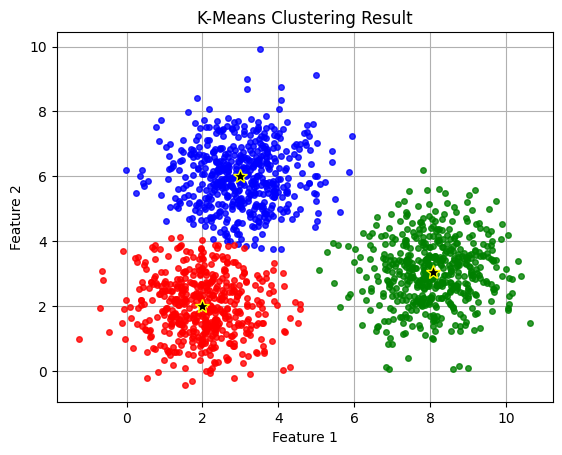

In [14]:
centroids , labels , iteration = kmeans(X  , K)
print(f"Center found :\n" , centroids[-1])
kmeans_display(X , labels[-1], centroids[-1])

In [15]:
model = KMeans(n_clusters = 3 , random_state = 0).fit(X)
print("Center found by scikit learn :")
print(model.cluster_centers_)

Center found by scikit learn :
[[8.06633167 3.06841999]
 [3.00188698 6.00855841]
 [1.98379957 1.99683971]]
